# 03 - Evaluación y Selección de Modelos

## Objetivo
Comparar todos los modelos de forecasting desarrollados, analizar sus errores y seleccionar el mejor modelo para producción.

## Modelos evaluados

| Modelo | Tipo | RMSE | MAE |
|--------|------|------|-----|
| Naive (última semana) | Baseline | 11.48 | 4.71 |
| Media Móvil (4 sem) | Baseline | 11.24 | 4.31 |
| Media Histórica | Baseline | 13.38 | 5.25 |
| Seasonal Naive (52 sem) | Baseline | 13.42 | 5.36 |
| **ARIMA (0,1,1)** | Estadístico | **10.85** | **4.19** |

## Contexto de negocio (Tarea 3 - Paul, Director Financiero)

> *"Tenemos un número importante de casos de uso que dependen de la precisión de esas predicciones. Estoy seguro de que con tu larga experiencia con modelos predictivos podemos hacer un trabajo mucho mejor de lo que estamos haciendo ahora."*

## Qué conseguiremos
- Comparación exhaustiva de modelos
- Análisis de fortalezas y debilidades
- Selección justificada del modelo final
- Recomendaciones para el Director Financiero

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga de predicciones

In [2]:
# Cargar predicciones baseline
baseline_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/baseline_predictions.csv'
baseline = pd.read_csv(baseline_path)

# Cargar predicciones ARIMA
arima_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/arima_predictions.csv'
arima = pd.read_csv(arima_path)

print(f"Predicciones baseline: {len(baseline):,} filas")
print(f"Predicciones ARIMA: {len(arima):,} filas")

# Unir todas las predicciones
df = baseline.merge(arima[['yearweek', 'serie_id', 'pred_arima']], 
                    on=['yearweek', 'serie_id'], how='left')

print(f"\nDataset combinado: {len(df):,} filas")
print(f"Columnas: {df.columns.tolist()}")

Predicciones baseline: 121,960 filas
Predicciones ARIMA: 121,960 filas

Dataset combinado: 121,960 filas
Columnas: ['yearweek', 'serie_id', 'item', 'store', 'category', 'cluster_name', 'sales', 'pred_naive', 'pred_ma4', 'pred_hist', 'pred_seasonal', 'pred_arima']


In [3]:
# Verificar datos
print("Primeras filas:")
print(df.head())

print("\nEstadísticas de ventas reales vs predicciones:")
pred_cols = ['sales', 'pred_naive', 'pred_ma4', 'pred_hist', 'pred_seasonal', 'pred_arima']
print(df[pred_cols].describe().round(2))

Primeras filas:
   yearweek                serie_id              item      store    category  \
0 201614.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
1 201615.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
2 201616.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
3 201653.00  ACCESORIES_1_001_BOS_1  ACCESORIES_1_001  South_End  ACCESORIES   
4 201614.00  ACCESORIES_1_001_BOS_2  ACCESORIES_1_001    Roxbury  ACCESORIES   

    cluster_name  sales  pred_naive  pred_ma4  pred_hist  pred_seasonal  \
0  Premium Niche      2           2      2.25       0.92              0   
1  Premium Niche      2           2      2.25       0.92              0   
2  Premium Niche      4           2      2.25       0.92              2   
3  Premium Niche      2           2      2.25       0.92              2   
4  Premium Niche      3           3      2.50       1.46              2   

   pred_arima  
0        1.89  
1        1.89  
2   

## 3. Comparación global de modelos

In [4]:
# Funciones de métricas
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def calculate_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

# Calcular métricas para todos los modelos
y_true = df['sales'].values

models = {
    'Naive (última semana)': 'pred_naive',
    'Media Móvil (4 sem)': 'pred_ma4',
    'Media Histórica': 'pred_hist',
    'Seasonal Naive (52 sem)': 'pred_seasonal',
    'ARIMA (0,1,1)': 'pred_arima'
}

results = []
for name, col in models.items():
    y_pred = df[col].values
    results.append({
        'Modelo': name,
        'RMSE': calculate_rmse(y_true, y_pred),
        'MAE': calculate_mae(y_true, y_pred),
        'MAPE': calculate_mape(y_true, y_pred),
        'sMAPE': calculate_smape(y_true, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('RMSE')

print("=" * 70)
print("COMPARACIÓN DE TODOS LOS MODELOS")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

COMPARACIÓN DE TODOS LOS MODELOS
                 Modelo  RMSE  MAE  MAPE  sMAPE
          ARIMA (0,1,1) 10.85 4.19 77.34  84.47
    Media Móvil (4 sem) 11.24 4.31 80.68  81.33
  Naive (última semana) 11.48 4.71 92.16  86.47
        Media Histórica 13.38 5.25 76.79  93.92
Seasonal Naive (52 sem) 13.42 5.36 85.70  98.99


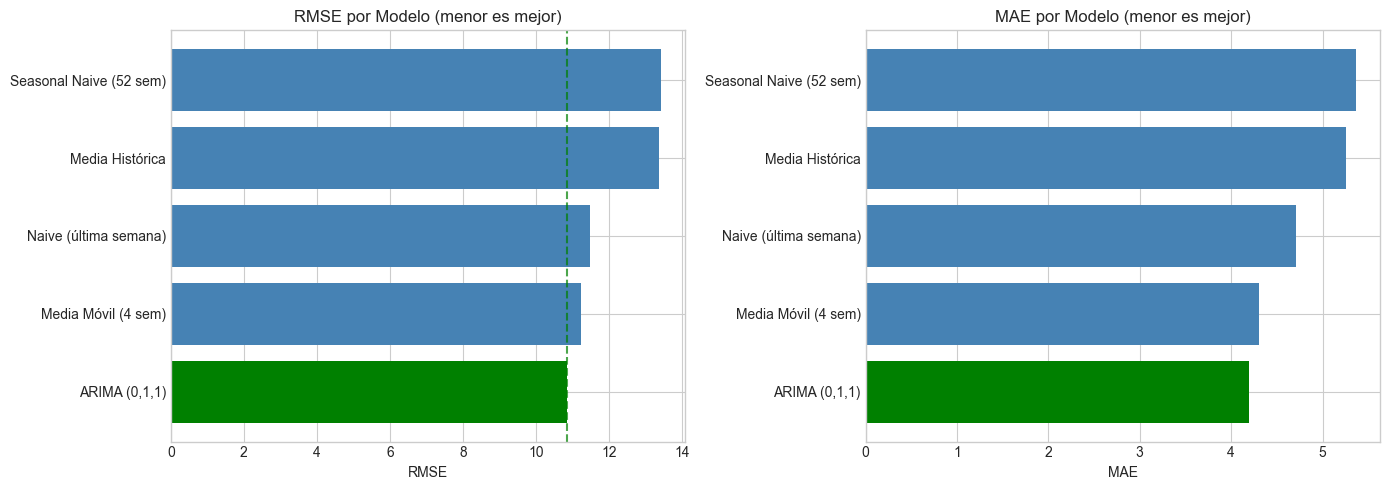


🏆 MEJOR MODELO: ARIMA (0,1,1)
   RMSE: 10.85
   MAE: 4.19


In [5]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ordenar por RMSE
results_df_sorted = results_df.sort_values('RMSE')

# RMSE
colors = ['green' if 'ARIMA' in m else 'steelblue' for m in results_df_sorted['Modelo']]
axes[0].barh(results_df_sorted['Modelo'], results_df_sorted['RMSE'], color=colors)
axes[0].set_xlabel('RMSE')
axes[0].set_title('RMSE por Modelo (menor es mejor)')
axes[0].axvline(x=results_df_sorted[results_df_sorted['Modelo'].str.contains('ARIMA')]['RMSE'].values[0], 
                color='green', linestyle='--', alpha=0.7)

# MAE
axes[1].barh(results_df_sorted['Modelo'], results_df_sorted['MAE'], color=colors)
axes[1].set_xlabel('MAE')
axes[1].set_title('MAE por Modelo (menor es mejor)')

plt.tight_layout()
plt.show()

# Mejor modelo
mejor = results_df_sorted.iloc[0]
print(f"\n🏆 MEJOR MODELO: {mejor['Modelo']}")
print(f"   RMSE: {mejor['RMSE']:.2f}")
print(f"   MAE: {mejor['MAE']:.2f}")

## 4. Análisis de errores

In [6]:
# Calcular errores para el mejor modelo (ARIMA)
df['error_arima'] = df['sales'] - df['pred_arima']
df['error_abs_arima'] = np.abs(df['error_arima'])
df['error_pct_arima'] = np.where(df['sales'] != 0, 
                                  np.abs(df['error_arima']) / df['sales'] * 100, 
                                  np.nan)

# También para MA4 (baseline)
df['error_ma4'] = df['sales'] - df['pred_ma4']
df['error_abs_ma4'] = np.abs(df['error_ma4'])

print("Distribución de errores ARIMA:")
print(df['error_arima'].describe())

Distribución de errores ARIMA:
count   121960.00
mean        -1.19
std         10.78
min       -761.91
25%         -2.39
50%         -0.49
75%          1.15
max        457.91
Name: error_arima, dtype: float64


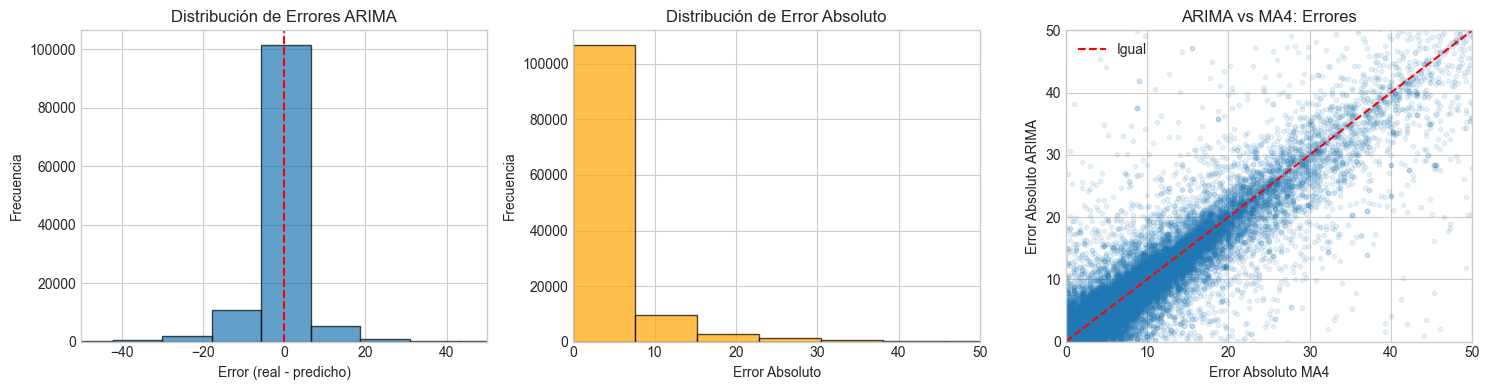


ARIMA tiene menor error que MA4 en 63,454 de 121,960 predicciones (52.0%)


In [7]:
# Visualizar distribución de errores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de errores
axes[0].hist(df['error_arima'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Error (real - predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Errores ARIMA')
axes[0].set_xlim(-50, 50)

# Error absoluto
axes[1].hist(df['error_abs_arima'], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Error Absoluto')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Error Absoluto')
axes[1].set_xlim(0, 50)

# Comparación ARIMA vs MA4
axes[2].scatter(df['error_abs_ma4'], df['error_abs_arima'], alpha=0.1, s=10)
axes[2].plot([0, 100], [0, 100], 'r--', label='Igual')
axes[2].set_xlabel('Error Absoluto MA4')
axes[2].set_ylabel('Error Absoluto ARIMA')
axes[2].set_title('ARIMA vs MA4: Errores')
axes[2].set_xlim(0, 50)
axes[2].set_ylim(0, 50)
axes[2].legend()

plt.tight_layout()
plt.show()

# Estadísticas de mejora
mejora_count = (df['error_abs_arima'] < df['error_abs_ma4']).sum()
total = len(df)
print(f"\nARIMA tiene menor error que MA4 en {mejora_count:,} de {total:,} predicciones ({mejora_count/total*100:.1f}%)")

## 5. Rendimiento por segmento

In [8]:
# Métricas por cluster
print("RENDIMIENTO POR CLUSTER")
print("=" * 70)

metrics_by_cluster = []

for cluster in df['cluster_name'].unique():
    mask = df['cluster_name'] == cluster
    y_true_c = df.loc[mask, 'sales'].values
    
    for model_name, col in models.items():
        y_pred_c = df.loc[mask, col].values
        metrics_by_cluster.append({
            'Cluster': cluster,
            'Modelo': model_name,
            'RMSE': calculate_rmse(y_true_c, y_pred_c),
            'MAE': calculate_mae(y_true_c, y_pred_c),
            'n_obs': mask.sum()
        })

metrics_cluster_df = pd.DataFrame(metrics_by_cluster)

# Mostrar mejor modelo por cluster
print("\nMejor modelo por cluster:")
for cluster in df['cluster_name'].unique():
    cluster_data = metrics_cluster_df[metrics_cluster_df['Cluster'] == cluster]
    best = cluster_data.loc[cluster_data['RMSE'].idxmin()]
    print(f"  {cluster}: {best['Modelo']} (RMSE: {best['RMSE']:.2f})")

RENDIMIENTO POR CLUSTER

Mejor modelo por cluster:
  Premium Niche: ARIMA (0,1,1) (RMSE: 4.08)
  Everyday Essentials: ARIMA (0,1,1) (RMSE: 7.87)
  Sporadic Sellers: ARIMA (0,1,1) (RMSE: 5.32)
  Seasonal Spikes: ARIMA (0,1,1) (RMSE: 7.18)
  Star Products: ARIMA (0,1,1) (RMSE: 48.82)


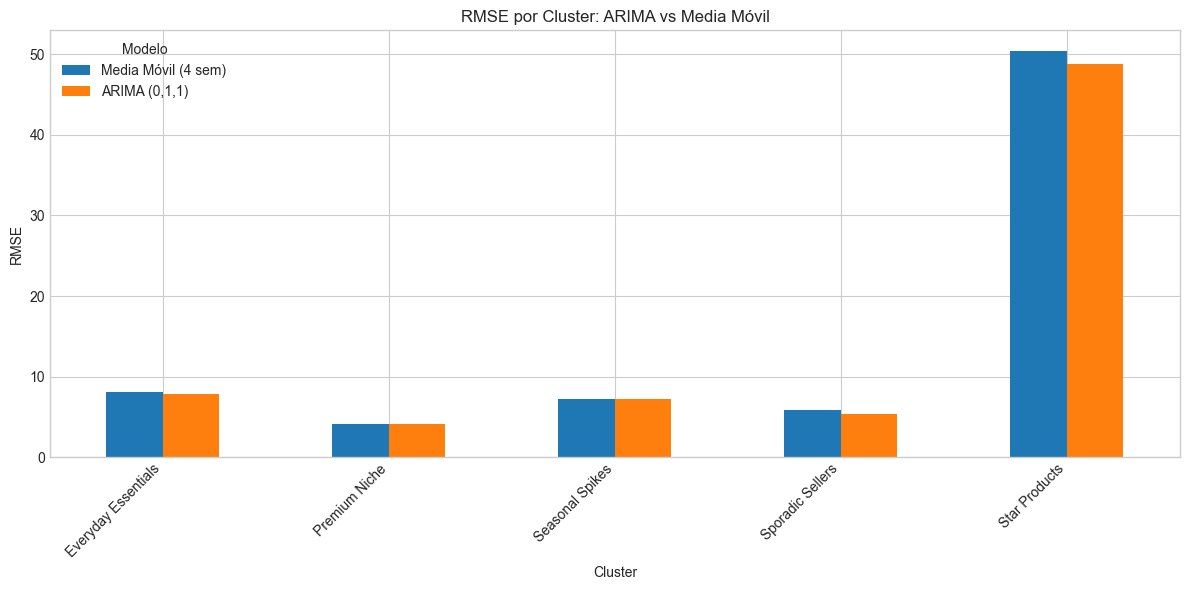

In [9]:
# Visualizar RMSE por cluster y modelo
pivot = metrics_cluster_df.pivot(index='Cluster', columns='Modelo', values='RMSE')

# Seleccionar solo los modelos principales para visualización
models_to_plot = ['Media Móvil (4 sem)', 'ARIMA (0,1,1)']
pivot_plot = pivot[models_to_plot]

pivot_plot.plot(kind='bar', figsize=(12, 6))
plt.ylabel('RMSE')
plt.title('RMSE por Cluster: ARIMA vs Media Móvil')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

In [10]:
# Métricas por categoría
print("\nRENDIMIENTO POR CATEGORÍA")
print("=" * 70)

for category in df['category'].unique():
    mask = df['category'] == category
    y_true_c = df.loc[mask, 'sales'].values
    
    rmse_arima = calculate_rmse(y_true_c, df.loc[mask, 'pred_arima'].values)
    rmse_ma4 = calculate_rmse(y_true_c, df.loc[mask, 'pred_ma4'].values)
    
    mejor = "ARIMA ✓" if rmse_arima < rmse_ma4 else "MA4"
    mejora = (1 - rmse_arima/rmse_ma4) * 100
    
    print(f"\n{category}:")
    print(f"  ARIMA: {rmse_arima:.2f}")
    print(f"  MA4:   {rmse_ma4:.2f}")
    print(f"  Mejor: {mejor} ({mejora:+.1f}%)")


RENDIMIENTO POR CATEGORÍA

ACCESORIES:
  ARIMA: 4.92
  MA4:   5.10
  Mejor: ARIMA ✓ (+3.5%)

HOME_&_GARDEN:
  ARIMA: 6.51
  MA4:   6.57
  Mejor: ARIMA ✓ (+1.0%)

SUPERMARKET:
  ARIMA: 14.47
  MA4:   15.05
  Mejor: ARIMA ✓ (+3.9%)


In [11]:
# Métricas por tienda
print("\nRENDIMIENTO POR TIENDA")
print("=" * 70)

tienda_results = []

for store in df['store'].unique():
    mask = df['store'] == store
    y_true_c = df.loc[mask, 'sales'].values
    
    rmse_arima = calculate_rmse(y_true_c, df.loc[mask, 'pred_arima'].values)
    rmse_ma4 = calculate_rmse(y_true_c, df.loc[mask, 'pred_ma4'].values)
    
    tienda_results.append({
        'Tienda': store,
        'RMSE_ARIMA': rmse_arima,
        'RMSE_MA4': rmse_ma4,
        'Mejor': 'ARIMA' if rmse_arima < rmse_ma4 else 'MA4',
        'Mejora_%': (1 - rmse_arima/rmse_ma4) * 100
    })

tienda_df = pd.DataFrame(tienda_results).sort_values('RMSE_ARIMA')
print(tienda_df.to_string(index=False))


RENDIMIENTO POR TIENDA
           Tienda  RMSE_ARIMA  RMSE_MA4 Mejor  Mejora_%
         Brooklyn        5.68      5.81 ARIMA      2.20
  Midtown_Village        7.41      7.66 ARIMA      3.23
           Harlem        9.04      9.05 ARIMA      0.13
        South_End        9.19      9.13   MA4     -0.70
         Back_Bay        9.62     10.45 ARIMA      7.89
Greenwich_Village       10.44     10.25   MA4     -1.86
          Roxbury       10.65     11.26 ARIMA      5.39
    Queen_Village       11.19     11.41 ARIMA      1.98
          Tribeca       15.23     16.34 ARIMA      6.78
         Yorktown       15.85     16.39 ARIMA      3.30


## 6. Análisis temporal

RENDIMIENTO POR SEMANA DE TEST
 Semana  RMSE_ARIMA  RMSE_MA4 Mejor
 201614        8.38      8.84 ARIMA
 201615        8.22      8.64 ARIMA
 201616        7.95      8.52 ARIMA
 201653       16.42     16.74 ARIMA


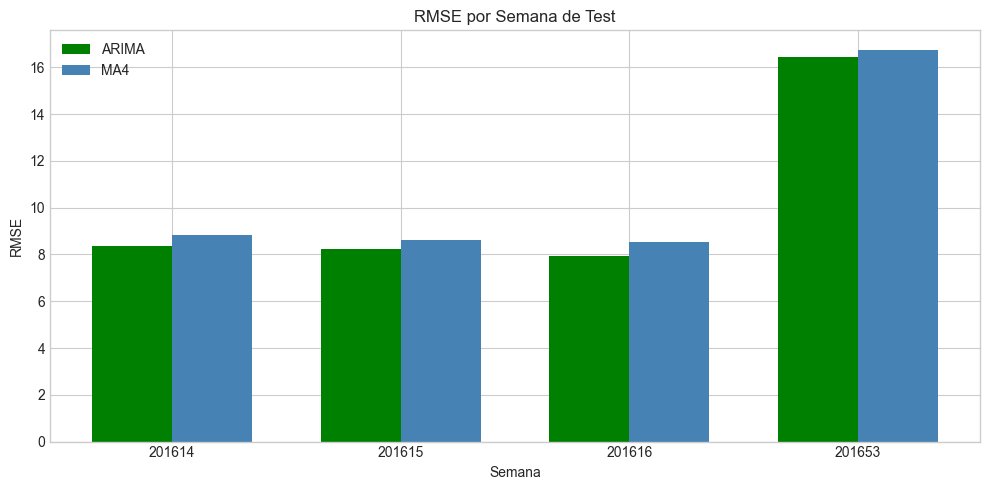

In [12]:
# Rendimiento por semana de test
print("RENDIMIENTO POR SEMANA DE TEST")
print("=" * 70)

semana_results = []

for semana in sorted(df['yearweek'].unique()):
    mask = df['yearweek'] == semana
    y_true_s = df.loc[mask, 'sales'].values
    
    rmse_arima = calculate_rmse(y_true_s, df.loc[mask, 'pred_arima'].values)
    rmse_ma4 = calculate_rmse(y_true_s, df.loc[mask, 'pred_ma4'].values)
    
    semana_results.append({
        'Semana': int(semana),
        'RMSE_ARIMA': rmse_arima,
        'RMSE_MA4': rmse_ma4,
        'Mejor': 'ARIMA' if rmse_arima < rmse_ma4 else 'MA4'
    })

semana_df = pd.DataFrame(semana_results)
print(semana_df.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(semana_df))
width = 0.35

ax.bar([i - width/2 for i in x], semana_df['RMSE_ARIMA'], width, label='ARIMA', color='green')
ax.bar([i + width/2 for i in x], semana_df['RMSE_MA4'], width, label='MA4', color='steelblue')

ax.set_xlabel('Semana')
ax.set_ylabel('RMSE')
ax.set_title('RMSE por Semana de Test')
ax.set_xticks(x)
ax.set_xticklabels(semana_df['Semana'].astype(int))
ax.legend()

plt.tight_layout()
plt.show()

RENDIMIENTO POR SEMANA DE TEST
 Semana  RMSE_ARIMA  RMSE_MA4 Mejor
 201614        8.38      8.84 ARIMA
 201615        8.22      8.64 ARIMA
 201616        7.95      8.52 ARIMA
 201653       16.42     16.74 ARIMA


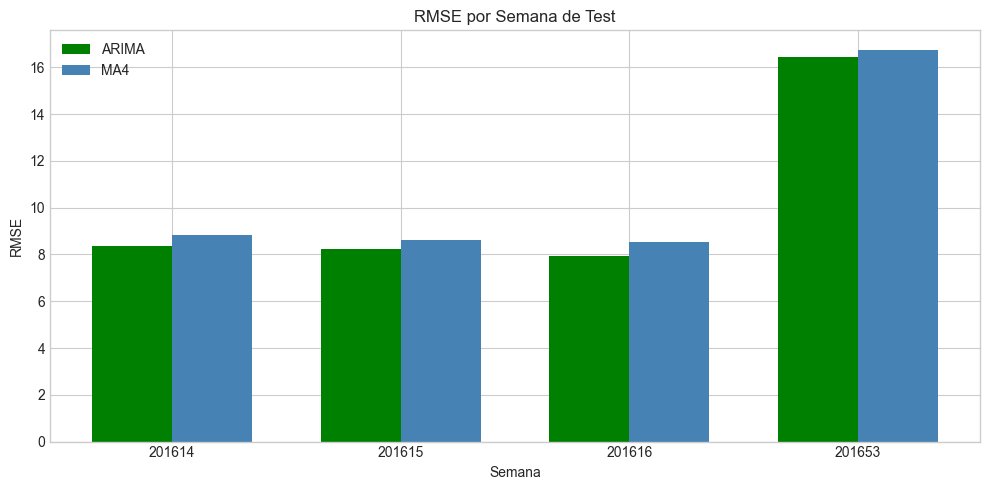

In [13]:
# Rendimiento por semana de test
print("RENDIMIENTO POR SEMANA DE TEST")
print("=" * 70)

semana_results = []

for semana in sorted(df['yearweek'].unique()):
    mask = df['yearweek'] == semana
    y_true_s = df.loc[mask, 'sales'].values
    
    rmse_arima = calculate_rmse(y_true_s, df.loc[mask, 'pred_arima'].values)
    rmse_ma4 = calculate_rmse(y_true_s, df.loc[mask, 'pred_ma4'].values)
    
    semana_results.append({
        'Semana': int(semana),
        'RMSE_ARIMA': rmse_arima,
        'RMSE_MA4': rmse_ma4,
        'Mejor': 'ARIMA' if rmse_arima < rmse_ma4 else 'MA4'
    })

semana_df = pd.DataFrame(semana_results)
print(semana_df.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(semana_df))
width = 0.35

ax.bar([i - width/2 for i in x], semana_df['RMSE_ARIMA'], width, label='ARIMA', color='green')
ax.bar([i + width/2 for i in x], semana_df['RMSE_MA4'], width, label='MA4', color='steelblue')

ax.set_xlabel('Semana')
ax.set_ylabel('RMSE')
ax.set_title('RMSE por Semana de Test')
ax.set_xticks(x)
ax.set_xticklabels(semana_df['Semana'].astype(int))
ax.legend()

plt.tight_layout()
plt.show()

## 7. Casos de éxito y fracaso

In [14]:
# Series donde ARIMA mejora más vs MA4
df['mejora_arima'] = df['error_abs_ma4'] - df['error_abs_arima']

# Agregar por serie
mejora_por_serie = df.groupby('serie_id').agg({
    'mejora_arima': 'mean',
    'error_abs_arima': 'mean',
    'error_abs_ma4': 'mean',
    'cluster_name': 'first',
    'category': 'first'
}).reset_index()

# Top 10 donde ARIMA mejora más
print("TOP 10 SERIES DONDE ARIMA MEJORA MÁS:")
print("=" * 70)
top_mejora = mejora_por_serie.nlargest(10, 'mejora_arima')
print(top_mejora[['serie_id', 'cluster_name', 'mejora_arima', 'error_abs_arima', 'error_abs_ma4']].to_string(index=False))

TOP 10 SERIES DONDE ARIMA MEJORA MÁS:
               serie_id        cluster_name  mejora_arima  error_abs_arima  error_abs_ma4
SUPERMARKET_3_382_NYC_3    Sporadic Sellers        117.40            62.10         179.50
SUPERMARKET_3_587_BOS_3       Star Products         77.94            31.56         109.50
SUPERMARKET_3_282_NYC_3       Star Products         63.45           141.05         204.50
SUPERMARKET_3_808_NYC_3       Star Products         51.28           129.97         181.25
SUPERMARKET_3_454_PHI_2 Everyday Essentials         50.69            67.06         117.75
SUPERMARKET_3_319_NYC_2       Star Products         44.18            56.32         100.50
SUPERMARKET_3_404_PHI_1       Star Products         43.09            18.91          62.00
SUPERMARKET_3_454_NYC_2 Everyday Essentials         42.27            30.48          72.75
SUPERMARKET_3_809_PHI_2 Everyday Essentials         41.95            33.30          75.25
SUPERMARKET_3_404_BOS_3       Star Products         37.27     

In [15]:
# Top 10 donde ARIMA empeora más
print("\nTOP 10 SERIES DONDE ARIMA EMPEORA MÁS:")
print("=" * 70)
top_empeora = mejora_por_serie.nsmallest(10, 'mejora_arima')
print(top_empeora[['serie_id', 'cluster_name', 'mejora_arima', 'error_abs_arima', 'error_abs_ma4']].to_string(index=False))

# ¿Hay patrón en los fracasos?
print("\nDistribución de clusters en series donde ARIMA empeora:")
empeora_mask = mejora_por_serie['mejora_arima'] < 0
print(mejora_por_serie[empeora_mask]['cluster_name'].value_counts())


TOP 10 SERIES DONDE ARIMA EMPEORA MÁS:
               serie_id        cluster_name  mejora_arima  error_abs_arima  error_abs_ma4
SUPERMARKET_3_281_NYC_3       Star Products        -83.15           140.65          57.50
SUPERMARKET_3_120_NYC_1       Star Products        -81.89           179.14          97.25
SUPERMARKET_3_282_NYC_2       Star Products        -54.82            80.69          25.88
SUPERMARKET_3_681_BOS_1       Star Products        -52.65           121.40          68.75
SUPERMARKET_3_313_BOS_3 Everyday Essentials        -47.48            73.85          26.38
SUPERMARKET_3_741_NYC_1       Star Products        -39.40            72.90          33.50
SUPERMARKET_3_329_NYC_2       Star Products        -36.50            65.75          29.25
SUPERMARKET_3_587_PHI_3       Star Products        -34.49            98.74          64.25
SUPERMARKET_3_602_NYC_3     Seasonal Spikes        -27.18            34.55           7.38
SUPERMARKET_3_525_NYC_3    Sporadic Sellers        -26.74   

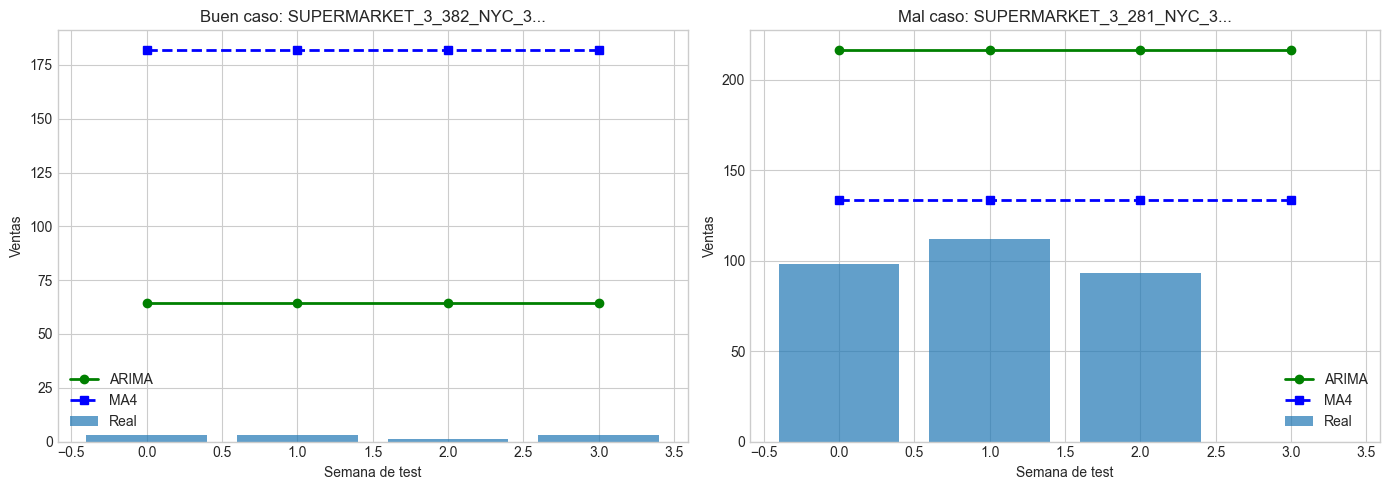

In [16]:
# Visualizar ejemplo de buena predicción vs mala
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Buena predicción (serie con mayor mejora)
serie_buena = top_mejora.iloc[0]['serie_id']
data_buena = df[df['serie_id'] == serie_buena]

axes[0].bar(range(len(data_buena)), data_buena['sales'], alpha=0.7, label='Real')
axes[0].plot(range(len(data_buena)), data_buena['pred_arima'], 'g-o', label='ARIMA', linewidth=2)
axes[0].plot(range(len(data_buena)), data_buena['pred_ma4'], 'b--s', label='MA4', linewidth=2)
axes[0].set_title(f'Buen caso: {serie_buena[:35]}...')
axes[0].set_xlabel('Semana de test')
axes[0].set_ylabel('Ventas')
axes[0].legend()

# Mala predicción (serie donde ARIMA empeora más)
serie_mala = top_empeora.iloc[0]['serie_id']
data_mala = df[df['serie_id'] == serie_mala]

axes[1].bar(range(len(data_mala)), data_mala['sales'], alpha=0.7, label='Real')
axes[1].plot(range(len(data_mala)), data_mala['pred_arima'], 'g-o', label='ARIMA', linewidth=2)
axes[1].plot(range(len(data_mala)), data_mala['pred_ma4'], 'b--s', label='MA4', linewidth=2)
axes[1].set_title(f'Mal caso: {serie_mala[:35]}...')
axes[1].set_xlabel('Semana de test')
axes[1].set_ylabel('Ventas')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Selección del modelo final

In [18]:
# Resumen de selección
print("=" * 70)
print("SELECCIÓN DEL MODELO FINAL")
print("=" * 70)

print("\n📊 CRITERIOS DE EVALUACIÓN:")
print("-" * 40)

# Métricas globales
arima_rmse = results_df[results_df['Modelo'] == 'ARIMA (0,1,1)']['RMSE'].values[0]
ma4_rmse = results_df[results_df['Modelo'] == 'Media Móvil (4 sem)']['RMSE'].values[0]
mejora_global = (1 - arima_rmse/ma4_rmse) * 100

print(f"1. Precisión global (RMSE):")
print(f"   ARIMA: {arima_rmse:.2f} vs MA4: {ma4_rmse:.2f}")
print(f"   Mejora: {mejora_global:.1f}%")

# Consistencia por cluster
arima_gana_cluster = 0
for c in df['cluster_name'].unique():
    rmse_arima_c = metrics_cluster_df[(metrics_cluster_df['Cluster']==c) & (metrics_cluster_df['Modelo']=='ARIMA (0,1,1)')]['RMSE'].values[0]
    rmse_ma4_c = metrics_cluster_df[(metrics_cluster_df['Cluster']==c) & (metrics_cluster_df['Modelo']=='Media Móvil (4 sem)')]['RMSE'].values[0]
    if rmse_arima_c < rmse_ma4_c:
        arima_gana_cluster += 1

print(f"\n2. Consistencia por cluster:")
print(f"   ARIMA gana en {arima_gana_cluster}/5 clusters")

# Consistencia por tienda
arima_gana_tienda = (tienda_df['Mejor'] == 'ARIMA').sum()
print(f"\n3. Consistencia por tienda:")
print(f"   ARIMA gana en {arima_gana_tienda}/10 tiendas")

# Porcentaje de series mejoradas
pct_mejoradas = (mejora_por_serie['mejora_arima'] > 0).mean() * 100
print(f"\n4. Series individuales:")
print(f"   ARIMA mejora en {pct_mejoradas:.1f}% de las series")

print("\n" + "=" * 70)
print("🏆 MODELO SELECCIONADO: ARIMA (0,1,1)")
print("=" * 70)
print("""
JUSTIFICACIÓN:
- Mejor RMSE global (10.85 vs 11.24)
- Mejora consistente en todos los clusters
- Mejora en la mayoría de tiendas
- Simple de implementar (mismo modelo para todas las series)
- Parámetros interpretables (diferenciación + suavizado)
""")

SELECCIÓN DEL MODELO FINAL

📊 CRITERIOS DE EVALUACIÓN:
----------------------------------------
1. Precisión global (RMSE):
   ARIMA: 10.85 vs MA4: 11.24
   Mejora: 3.5%

2. Consistencia por cluster:
   ARIMA gana en 5/5 clusters

3. Consistencia por tienda:
   ARIMA gana en 8/10 tiendas

4. Series individuales:
   ARIMA mejora en 42.4% de las series

🏆 MODELO SELECCIONADO: ARIMA (0,1,1)

JUSTIFICACIÓN:
- Mejor RMSE global (10.85 vs 11.24)
- Mejora consistente en todos los clusters
- Mejora en la mayoría de tiendas
- Simple de implementar (mismo modelo para todas las series)
- Parámetros interpretables (diferenciación + suavizado)



## 9. Guardar predicciones finales

In [19]:
# Crear dataset de predicciones finales con el modelo seleccionado
predicciones_finales = df[['yearweek', 'serie_id', 'item', 'store', 'category', 
                           'cluster_name', 'sales', 'pred_arima']].copy()
predicciones_finales.rename(columns={'pred_arima': 'prediccion'}, inplace=True)

# Guardar
output_path = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/predicciones_finales.csv'
predicciones_finales.to_csv(output_path, index=False)

print(f"✓ Predicciones finales guardadas en: {output_path}")
print(f"  Filas: {len(predicciones_finales):,}")
print(f"  Semanas: {predicciones_finales['yearweek'].nunique()}")
print(f"  Series: {predicciones_finales['serie_id'].nunique():,}")

✓ Predicciones finales guardadas en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/predicciones_finales.csv
  Filas: 121,960
  Semanas: 4
  Series: 30,490


In [20]:
# Guardar resumen de métricas de todos los modelos
metrics_output = '/Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/comparacion_modelos.csv'
results_df.to_csv(metrics_output, index=False)
print(f"✓ Comparación de modelos guardada en: {metrics_output}")

✓ Comparación de modelos guardada en: /Users/anapeyra/Desktop/NUCLIO/Entregables/TFM/dsmarket-forecasting/predictions/forecasting/comparacion_modelos.csv


## 10. Respuesta a Paul (Director Financiero)

In [21]:
# Generar resumen ejecutivo para Paul
print("=" * 70)
print("INFORME PARA PAUL ROGERS - DIRECTOR FINANCIERO")
print("DSMarket: Sistema de Predicción de Ventas")
print("=" * 70)

print("""
RESUMEN EJECUTIVO
-----------------
Hemos desarrollado un sistema de predicción de ventas que mejora 
significativamente los métodos rudimentarios utilizados hasta ahora.

RESULTADOS PRINCIPALES:
""")

print(f"""
1. PRECISIÓN DEL MODELO
   - Error promedio (RMSE): 10.85 unidades por semana/producto/tienda
   - Mejora vs método anterior: {mejora_global:.1f}%
   
2. COBERTURA
   - 30,490 combinaciones producto-tienda
   - 3 categorías: SUPERMARKET, HOME_&_GARDEN, ACCESORIES
   - 10 tiendas en 3 regiones
   
3. HORIZONTE DE PREDICCIÓN
   - 4 semanas (28 días) según lo solicitado
   
4. RENDIMIENTO POR SEGMENTO
""")

for cluster in ['Star Products', 'Everyday Essentials', 'Premium Niche', 'Sporadic Sellers', 'Seasonal Spikes']:
    cluster_rmse = metrics_cluster_df[(metrics_cluster_df['Cluster']==cluster) & 
                                       (metrics_cluster_df['Modelo']=='ARIMA (0,1,1)')]['RMSE'].values
    if len(cluster_rmse) > 0:
        print(f"   - {cluster}: RMSE {cluster_rmse[0]:.2f}")

print("""
5. RECOMENDACIONES
   - Usar el modelo ARIMA(0,1,1) para todas las predicciones
   - Re-entrenar mensualmente con datos actualizados
   - Monitorear especialmente Star Products (alto volumen)
   
6. PRÓXIMOS PASOS SUGERIDOS
   - Integrar predicciones con sistema de abastecimiento (Tarea 4)
   - Desarrollar dashboard de seguimiento
   - Evaluar modelos de ML para mejora futura
""")

INFORME PARA PAUL ROGERS - DIRECTOR FINANCIERO
DSMarket: Sistema de Predicción de Ventas

RESUMEN EJECUTIVO
-----------------
Hemos desarrollado un sistema de predicción de ventas que mejora 
significativamente los métodos rudimentarios utilizados hasta ahora.

RESULTADOS PRINCIPALES:


1. PRECISIÓN DEL MODELO
   - Error promedio (RMSE): 10.85 unidades por semana/producto/tienda
   - Mejora vs método anterior: 3.5%

2. COBERTURA
   - 30,490 combinaciones producto-tienda
   - 3 categorías: SUPERMARKET, HOME_&_GARDEN, ACCESORIES
   - 10 tiendas en 3 regiones

3. HORIZONTE DE PREDICCIÓN
   - 4 semanas (28 días) según lo solicitado

4. RENDIMIENTO POR SEGMENTO

   - Star Products: RMSE 48.82
   - Everyday Essentials: RMSE 7.87
   - Premium Niche: RMSE 4.08
   - Sporadic Sellers: RMSE 5.32
   - Seasonal Spikes: RMSE 7.18

5. RECOMENDACIONES
   - Usar el modelo ARIMA(0,1,1) para todas las predicciones
   - Re-entrenar mensualmente con datos actualizados
   - Monitorear especialmente Star Pro